# Simple Likelihood Ratio

Gaussian log likelihoods from the signal and background data are computed from the predicted chirp mass and their uncertainties.

### Setup

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
sig_csv_path = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/outputs/s4d_gaussnll_15_30_pre_match_filter/two_masses_59s_63s-d64-s64-l4/signal/signal.csv'
bkg_csv_path = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/outputs/s4d_gaussnll_15_30_pre_match_filter/two_masses_59s_63s-d64-s64-l4/background/background.csv'

In [40]:
def csv_to_df(csv_path):
    df = pd.read_csv(csv_path)
    return df

In [41]:
def chirp_mass_log_likelihood(df, true_col_name, pred_col_name, sigma_col_name):
    var = np.power(df[sigma_col_name], 2)
    first_term = - 0.5 * np.log(2 * np.pi * var)
    second_term = - np.divide(np.power((df[pred_col_name] - df[true_col_name]), 2), 2 * var)
    log_likelihood = first_term + second_term
    return log_likelihood

def chirp_mass_likelihood(log_likelihood):
    return np.exp(log_likelihood)

In [42]:
def log_likelihood_ratio(sig_log_likelihood, bkg_log_likelihood):
    return sig_log_likelihood - bkg_log_likelihood

def likelihood_ratio(sig_log_likelihood, bkg_log_likelihood):
    return np.exp(sig_log_likelihood - bkg_log_likelihood)

### Computation

In [43]:
sig_df = csv_to_df(sig_csv_path)
bkg_df = csv_to_df(bkg_csv_path)

In [44]:
sig_df.head()

,M_chirp_true,M_ratio_true,M_chirp_pred,M_ratio_pred,sigma_M_chirp_pred,sigma_M_ratio_pred
0,1.535631,0.768489,1.561787,0.718609,0.008768,0.135967
1,1.789680,0.700510,1.841984,0.829550,0.013648,0.084078
2,1.448813,0.927405,1.425266,0.695528,0.093260,0.173094
3,1.606030,0.806993,1.536141,0.773192,0.326327,0.143944
4,1.481367,0.525900,1.480670,0.729158,0.074991,0.143222


In [45]:
sig_ll = chirp_mass_log_likelihood(sig_df, 'M_chirp_true', 'M_chirp_pred', 'sigma_M_chirp_pred')
bkg_ll = chirp_mass_log_likelihood(bkg_df, 'M_chirp_true', 'M_chirp_pred', 'sigma_M_chirp_pred')
sig_l = chirp_mass_likelihood(sig_ll)
bkg_l = chirp_mass_likelihood(bkg_ll)

In [46]:
likelihood_ratio(sig_ll, bkg_ll)

0         0.997358
1         0.033674
2         4.130458
3         1.394368
4         5.013035
           ...    
14995    15.343984
14996     0.133448
14997     3.220050
14998    39.276151
14999     6.341182
Length: 15000, dtype: float64

### Visualization

1. Individual likelihoods

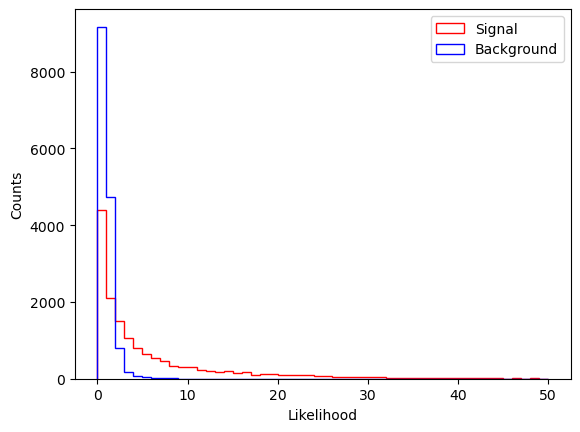

In [47]:
plt.hist(sig_l, bins=50, range=(0, 50), histtype='step', color='red', label='Signal')
plt.hist(bkg_l, bins=50, range=(0, 50), histtype='step', color='blue', label='Background')
plt.xlabel('Likelihood')
plt.ylabel('Counts')
plt.legend()
plt.show()

2. Uncertainties

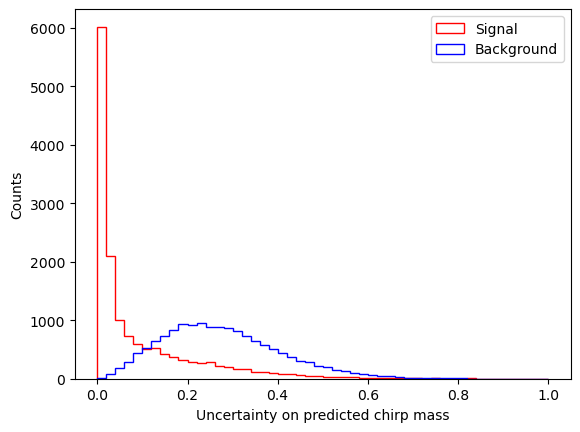

In [48]:
plt.hist(sig_df['sigma_M_chirp_pred'], bins=50, range=(0, 1), histtype='step', color='red', label='Signal')
plt.hist(bkg_df['sigma_M_chirp_pred'], bins=50, range=(0, 1), histtype='step', color='blue', label='Background')
plt.xlabel('Uncertainty on predicted chirp mass')
plt.ylabel('Counts')
plt.legend()
plt.show()

3. Chirp Mass

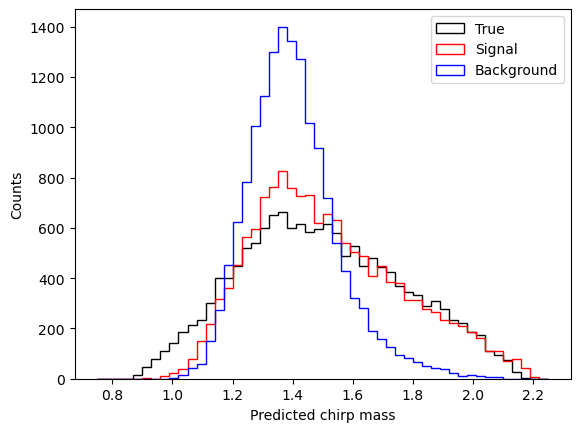

In [52]:
plt.hist(sig_df['M_chirp_true'], bins=50, range=(0.75, 2.25), histtype='step', color='black', label='True')
plt.hist(sig_df['M_chirp_pred'], bins=50, range=(0.75, 2.25), histtype='step', color='red', label='Signal')
plt.hist(bkg_df['M_chirp_pred'], bins=50, range=(0.75, 2.25), histtype='step', color='blue', label='Background')
plt.xlabel('Predicted chirp mass')
plt.ylabel('Counts')
plt.legend()
plt.show()